# Laboratorio 2 - Mineria de datos
- Fabian Prado # 23427 
- Jonathan Zacarías # 231104 
- Sofia López # 231929

### Imports

In [66]:
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

## Cluster

### Data Loading

In [51]:
df_movies = pd.read_csv('movies_2026.csv', encoding='utf-8', encoding_errors='ignore')

In [52]:
df_movies.head()

,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


Para la clusterizacion, eliminaremos variables que no aporten un valor numerico, y representen informacion de identificador. Las variables de este tipo son:
id, genres, homePage, productionCompany, productionCompanyCountry, productionCountry, director, releaseDate, actors, actorsCharacter, originalTitle, title, originalLanguage

Por otro lado, las variables que usaremos son:
budget, revenue, runtime, video, actorsPopularity_mean, popularity, voteAvg, voteCount, genresAmount, productionCoAmount, productionCountriesAmount, actorsAmount, castWomenAmount, castMenAmount, releaseYear

### Data Processing

In [53]:
# Funcion para calcular la media de popularidad de los actores
def parse_actor_popularity_mean(popularity_str):
    try:
        values = [float(x) for x in str(popularity_str).split('|') if x.strip() != '']
        return np.mean(values) if values else np.nan
    except:
        return np.nan

In [54]:
# Agregar la nueva columna con la media de popularidad de los actores
df_movies['actorsPopularity_mean'] = df_movies['actorsPopularity'].apply(parse_actor_popularity_mean)

# Seleccionar las variables para el clustering
clustering_vars = [
    'budget', 'revenue', 'runtime', 'video',
    'actorsPopularity_mean', 'popularity', 'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount',
    'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear'
]

df_cluster = df_movies[clustering_vars].copy()

### Limpieza de datos

Ya que al hacer la primera clusterizacion encontramos clusters con datos erroneos (como actorsAmount > 500k), se decidio hacerle un cap en el 98 percentil

In [55]:
men_threshold = df_cluster['castMenAmount'].quantile(0.98)
women_threshold = df_cluster['castWomenAmount'].quantile(0.98)

mask_actors = (df_cluster['castMenAmount'] <= men_threshold) & (df_cluster['castWomenAmount'] <= women_threshold)
df_cluster = df_cluster[mask_actors].copy()

df_cluster['video'] = df_cluster['video'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)

df_cluster['budget']  = df_cluster['budget'].replace(0, np.nan)
df_cluster['revenue'] = df_cluster['revenue'].replace(0, np.nan)

df_cluster.fillna(df_cluster.median(numeric_only=True), inplace=True)

df_cluster.to_csv('movies_data_clean.csv', index=False)

# Escalar las variables para el clustering usando z-score
scaler = StandardScaler()
df_cluster_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster),
    columns=clustering_vars
)

df_cluster_scaled.head()

,budget,revenue,runtime,video,actorsPopularity_mean,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,-0.20527,-0.176587,0.602878,-0.047519,-0.857295,-0.159003,-1.09267,-0.34918,0.048292,-0.897171,-1.29509,-0.390148,-0.332554,-0.206193,0.697162
1,-0.20527,-0.176587,-1.244602,-0.047519,-0.979741,-0.159003,-1.09267,-0.34918,-0.749714,-0.897171,-1.29509,-0.617277,-0.778811,-0.736199,0.697162
2,-0.20527,-0.176587,-1.264683,-0.047519,-0.976630,-0.159094,-1.09267,-0.34918,-0.749714,-0.897171,-1.29509,-0.674059,-0.778811,-0.736199,0.697162
3,-0.20527,-0.176587,-1.204439,-0.047519,-0.980326,-0.158958,-1.09267,-0.34918,0.846298,-0.897171,-1.29509,-0.446930,-0.778811,-0.736199,0.697162
4,-0.20527,-0.176587,-1.063870,-0.047519,-0.977422,-0.158989,-1.09267,-0.34918,-0.749714,-0.897171,-1.29509,-0.674059,-0.778811,-0.736199,0.697162


### Hopkings y la VAT 

Por el tamaño del Dataset, no estaremos usando VAT, ya que la matrix resultante no seria legible y no es tan poderoso el analisis en un sample de la data; por otro lado, usaremos un sample del ~10% para Hopkins (2000)

In [56]:
def hopkins_test(X, sample_ratio=0.10):
    data = np.array(X)
    n_samples, n_features = data.shape
    sample_size = int(sample_ratio * n_samples)
    
    neighbors = NearestNeighbors(n_neighbors=2).fit(data)
    
    # Distancia de puntos reales a su vecino más cercano
    random_idx = random.sample(range(n_samples), sample_size)
    real_sample = data[random_idx]
    real_distances, _ = neighbors.kneighbors(real_sample, n_neighbors=2)
    real_distances = real_distances[:, 1]  # no consideramos la distancia a sí mismo
    
    # Distancia de puntos sintéticos a su vecino más cercano
    min_vals = data.min(axis=0)
    max_vals = data.max(axis=0)
    synthetic_sample = np.random.uniform(low=min_vals, high=max_vals, size=(sample_size, n_features))
    synthetic_distances, _ = neighbors.kneighbors(synthetic_sample, n_neighbors=1)
    synthetic_distances = synthetic_distances[:, 0]
    
    hopkins = synthetic_distances.sum() / (synthetic_distances.sum() + real_distances.sum())
    
    return hopkins

In [57]:
H = hopkins_test(df_cluster_scaled)
print(f"Hopkins Statistic: {H:.4f}")
if H > 0.75:
    print("> Strong clustering tendency.")
elif H > 0.5:
    print("> Moderate clustering tendency.")
else:
    print("> Data does not show strong clustering tendency.")

Hopkins Statistic: 0.9739
> Strong clustering tendency.


Ya que nuestro Estadistica de Hopkins es 0.9737 vemos que nuestro dataset si tiene tendencia a ser clusterizado.

### Elbow Graph

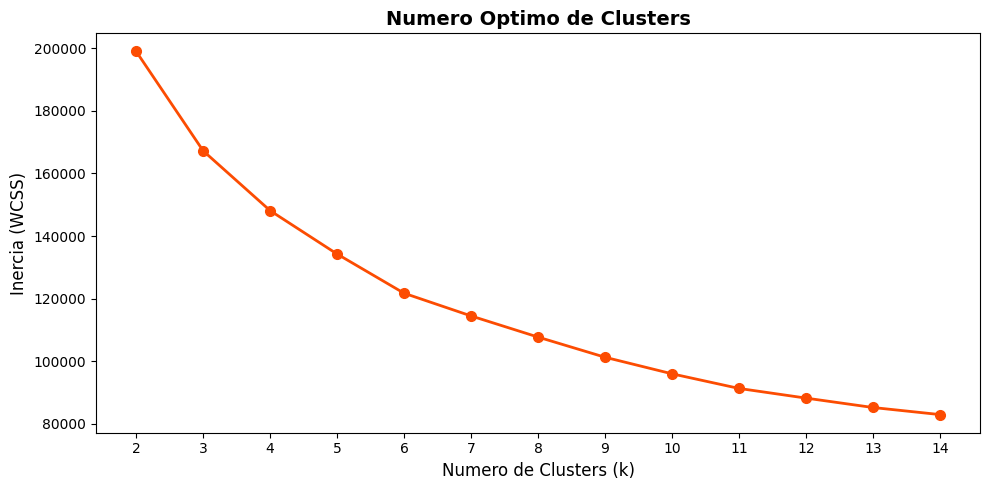

In [58]:
inertia_values = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning) 
        kmeans.fit(df_cluster_scaled)
    inertia_values.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, inertia_values, marker='o', color='#FC4C02', linewidth=2, markersize=7)
ax.set_xlabel('Numero de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia (WCSS)', fontsize=12)
ax.set_title('Numero Optimo de Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(False) # odio el grid

plt.tight_layout()
plt.show()

En base al Elbow Method usaremos **4 clusters**

### K-means

In [59]:
n_clusters = 4

kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    df_cluster['cluster_kmeans'] = kmeans_model.fit_predict(df_cluster_scaled)

print("Cluster sizes (K-Means):")
df_cluster['cluster_kmeans'].value_counts().sort_index()

Cluster sizes (K-Means):


cluster_kmeans
0    9978
1     781
2    8284
3      43
Name: count, dtype: int64

### Clustering jerárquico

In [60]:
hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df_cluster['cluster_hierarchical'] = hierarchical_model.fit_predict(df_cluster_scaled)

print("Cluster sizes (Hierarchical):")
df_cluster['cluster_hierarchical'].value_counts().sort_index()

Cluster sizes (Hierarchical):


cluster_hierarchical
0     8411
1    10419
2      213
3       43
Name: count, dtype: int64

En base a ambos metodos de clusterizacion, podemos ver que hay dos clusters con ~50% de las peliculas, y dos grupos de outliers, que podrian ser: indies, blockbusters o peliculas muy caras pero no generaron nada

### Silhoutte

In [61]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    kmeans_silhouette = silhouette_score(
        df_cluster_scaled,
        df_cluster["cluster_kmeans"],
        sample_size=2000,
        random_state=42
    )

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    hierarchical_silhouette = silhouette_score(
        df_cluster_scaled,
        df_cluster["cluster_hierarchical"],
        sample_size=2000,
        random_state=42
    )

print(f"K-Means Silhouette Score:      {kmeans_silhouette:.4f}")
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette:.4f}")

K-Means Silhouette Score:      0.3791
Hierarchical Silhouette Score: 0.3711


Ya que el Silhoutte score de K-means es mas alto (aunque no existe una diferencia muy grande) usaremos el K-Means

### INTERPRETACION

In [ ]:
df_interpret = df_cluster.copy()
df_interpret["cluster"] = df_cluster["cluster_kmeans"]

continuous_vars = [
    'budget', 'revenue', 'runtime',
    'actorsPopularity_mean', 'popularity',
    'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount',
    'actorsAmount', 'castWomenAmount', 'castMenAmount',
    'releaseYear'
]

# Calcular estadísticas descriptivas por cluster
cluster_summary = (
    df_interpret
    .groupby("cluster")[continuous_vars]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
cluster_summary

budget                                                   \
                 mean      median          std        min          max   
cluster                                                                  
0        1.031811e+07  12000000.0   4165842.41        1.0   30000000.0   
1        1.034760e+08  97600000.0  59279551.88  3000000.0  380000000.0   
2        1.689857e+07  12000000.0  15904084.51        5.0  150000000.0   
3        1.434884e+07  12000000.0  13501116.36       50.0   80000000.0   

              revenue                                                      \
                 mean       median           std        min           max   
cluster                                                                     
0        3.543294e+07   36000000.0  4.494101e+06        1.0  7.379788e+07   
1        3.922612e+08  309232797.0  2.964478e+08   178143.0  2.847246e+09   
2        4.230628e+07   36000000.0  4.181797e+07        1.0  7.425000e+08   
3        3.364023e+07   36000000.0  7.969084e+06  2600000.0  3.600000e+07   

         ... castMenAmount                          releaseYear          \
         ...          mean median    std  min   max        mean  median   
cluster  ...                                                              
0        ...          0.95    0.0   1.74  0.0  12.0     2024.96  2025.0   
1        ...         28.21   26.0  12.91  3.0  70.0     2008.59  2011.0   
2        ...         12.15   10.0   8.50  0.0  70.0     2008.29  2013.0   
3        ...          8.79    5.0   9.68  0.0  38.0     2012.84  2014.0   

                                
           std     min     max  
cluster                         
0         1.78  2001.0  2026.0  
1         9.09  1951.0  2025.0  
2        14.52  1902.0  2026.0  
3         5.48  2002.0  2021.0  

[4 rows x 70 columns]

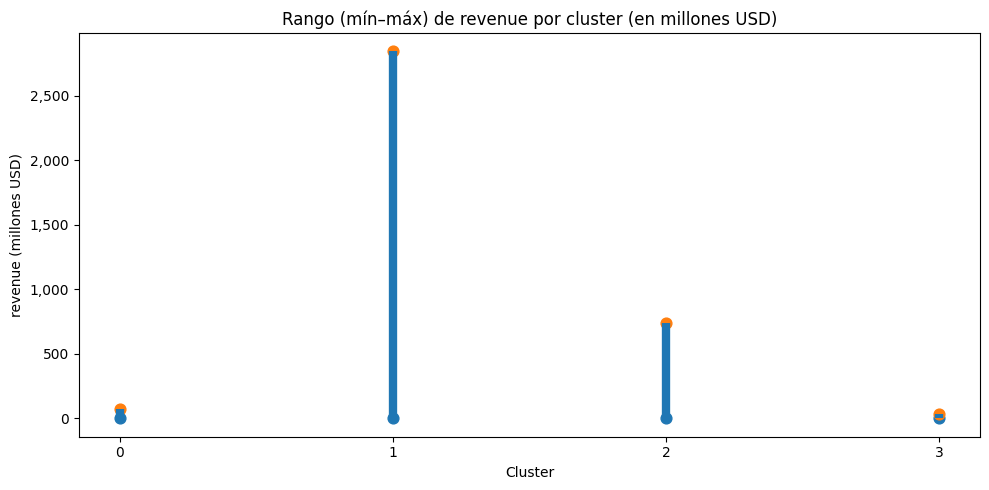

In [ ]:
def min_max_by_cluster(df, col, cluster_col="cluster", scale="millions"):
    stats = df.groupby(cluster_col)[col].agg(["min", "max"]).sort_index()

    if scale == "millions":
        factor = 1_000_000
        y_label = f"{col} (millones USD)"
        title = f"Rango (min max) de {col} por cluster (en millones USD)"
        fmt = "{x:,.0f}"   # enteros en millones
    elif scale == "hundredk":
        factor = 100_000
        y_label = f"{col} (cientos de miles USD)"
        title = f"Rango (min max) de {col} por cluster (en cientos de miles USD)"
        fmt = "{x:,.0f}"
    elif scale == "thousands":
        factor = 1_000
        y_label = f"{col} (miles USD)"
        title = f"Rango (min max) de {col} por cluster (en miles USD)"
        fmt = "{x:,.0f}"
    else:
        factor = 1
        y_label = f"{col} (USD)"
        title = f"Rango (min max) de {col} por cluster"
        fmt = "{x:,.0f}"

    ymin = stats["min"].values / factor
    ymax = stats["max"].values / factor
    x = np.arange(len(stats.index))

    plt.figure(figsize=(10, 5))
    plt.vlines(x, ymin, ymax, linewidth=6)
    plt.scatter(x, ymin, s=60, label="Mínimo")
    plt.scatter(x, ymax, s=60, label="Máximo")

    plt.xticks(x, stats.index)
    plt.xlabel("Cluster")
    plt.ylabel(y_label)
    plt.title(title)

    ax = plt.gca()
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter(fmt))

    plt.tight_layout()
    plt.show()

min_max_by_cluster(df_interpret, "revenue", scale="millions")

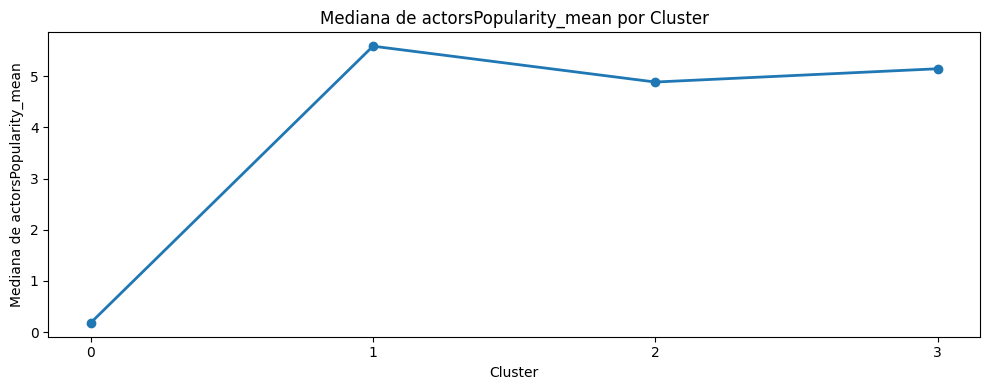

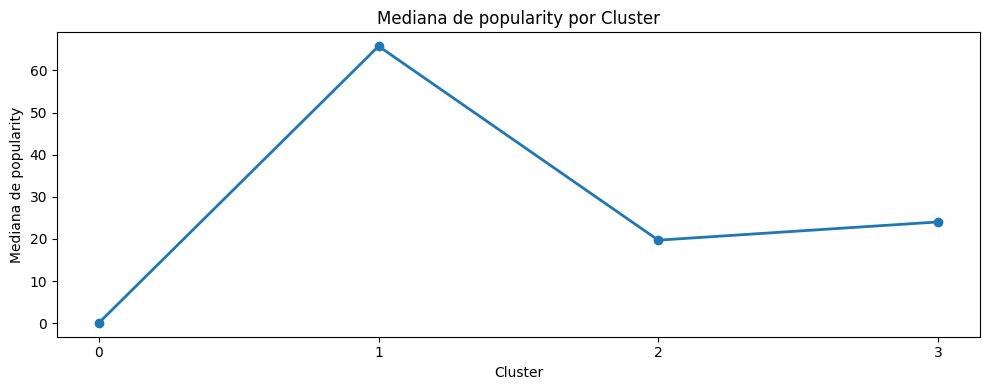

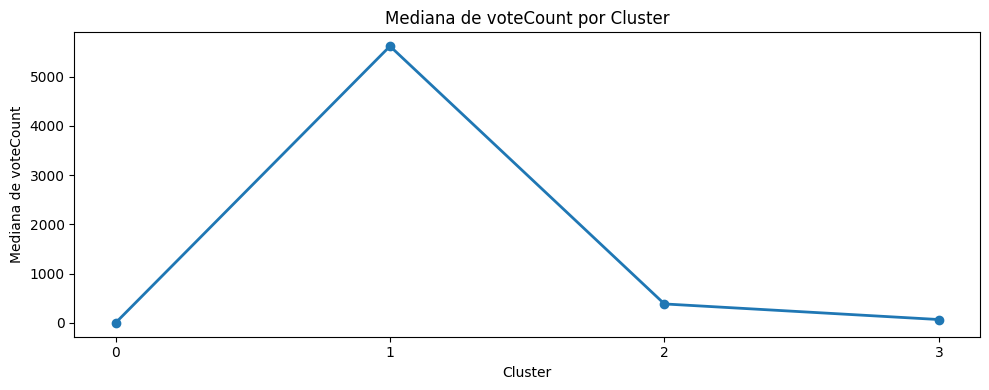

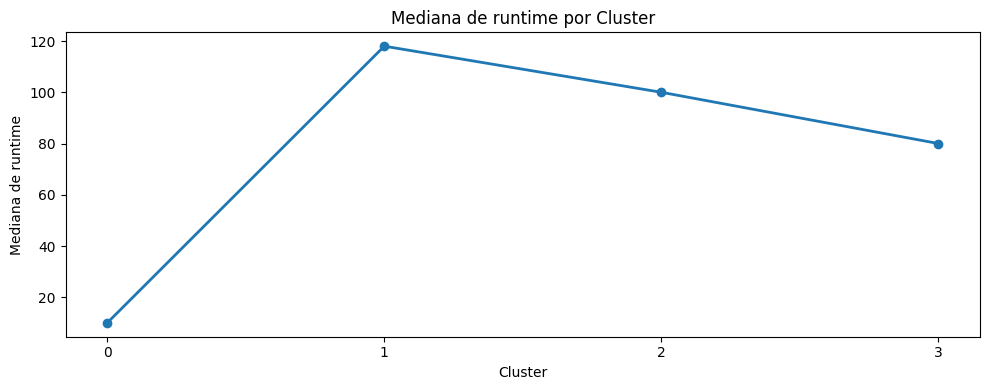

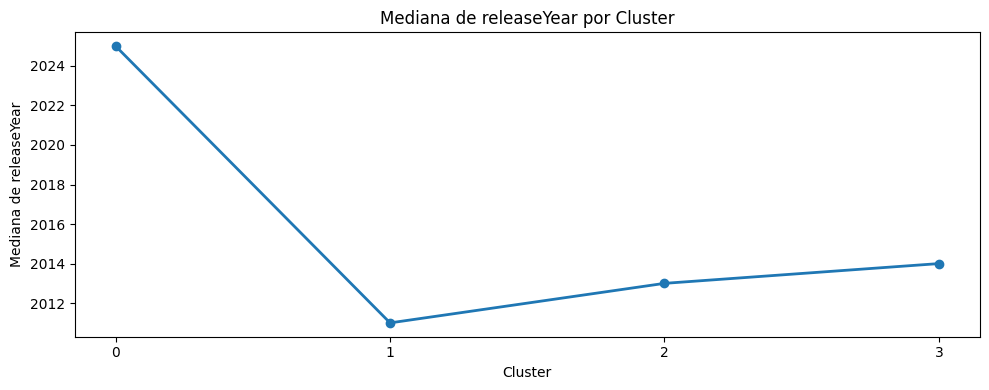

In [64]:
vars_median = ["actorsPopularity_mean", "popularity", "voteCount", "runtime", "releaseYear"]

medians = df_interpret.groupby("cluster")[vars_median].median().sort_index()

for col in vars_median:
    plt.figure(figsize=(10, 4))
    plt.plot(medians.index, medians[col].values, marker="o", linewidth=2)
    plt.xticks(medians.index)
    plt.xlabel("Cluster")
    plt.ylabel(f"Mediana de {col}")
    plt.title(f"Mediana de {col} por Cluster")
    plt.tight_layout()
    plt.show()

**Cluster 1 (blockbusters)**
- revenue max más alto por mucho (~2,800–2,900 millones USD).
- Medianas más altas en popularity, voteCount y actorsPopularity_mean.
- runtime más largo (~118 min).
- Idea: películas extremadamente famosas / mucha gente las califica.
- Sirve para: identificar las peliculas mas grandes "hits" y compararlas contra el resto.

**Cluster 2 (éxito medio)**
- revenue max medio-alto (~700–800 millones USD).
- popularity y voteCount medianos.
- runtime medio (~100 min).
- Idea: películas comerciales normales, buen desempeño pero no top.
- Sirve para: ver qué hace falta para pasar de “normal” a “hit”.

**Cluster 3 (cast conocido pero poca interacción)**
- actorsPopularity_mean alto, pero voteCount bajo (~100).
- popularity media (~24).
- runtime más corto (~80 min).
- Idea: actores conocidos, pero no tuvo tanta audiencia/ratings.
- Sirve para: detectar peliculas con “buen cast” pero poco alcance.

**Cluster 0 (recientes/ indies)**
- revenue y budget bajos.
- popularity, voteCount, actorsPopularity_mean casi en 0.
- releaseYear más reciente (~2025).
- Idea: nuevas o de bajo perfil (poca data/menos vistas/indie).
- Sirve para: identificar las peliculas menos rentables